In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GroupKFold, StratifiedKFold, train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import classification_report, precision_score, recall_score, accuracy_score, confusion_matrix, roc_curve, precision_recall_curve, auc, f1_score
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.feature_selection import RFE, SelectFromModel
from xgboost import XGBClassifier, plot_importance
from IPython import display
from datetime import datetime
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib import cm

from pylab import rcParams

import os
import re
import time

In [2]:
X = pd.read_csv('/kaggle/input/datasets/thuhiuhong/base-clean/stage1_base_clean.csv')

In [3]:
# Event-wise distribution
event_dist = X['SepsisLabel'].value_counts(normalize=True) * 100
print("Event-wise distribution (%)")
print(event_dist)

# Patient-wise distribution
patient_label = X.groupby('id')['SepsisLabel'].max()
patient_dist = patient_label.value_counts(normalize=True) * 100
print("\nPatient-wise distribution (%)")
print(patient_dist)


Event-wise distribution (%)
SepsisLabel
0    98.201532
1     1.798468
Name: proportion, dtype: float64

Patient-wise distribution (%)
SepsisLabel
0    92.731059
1     7.268941
Name: proportion, dtype: float64


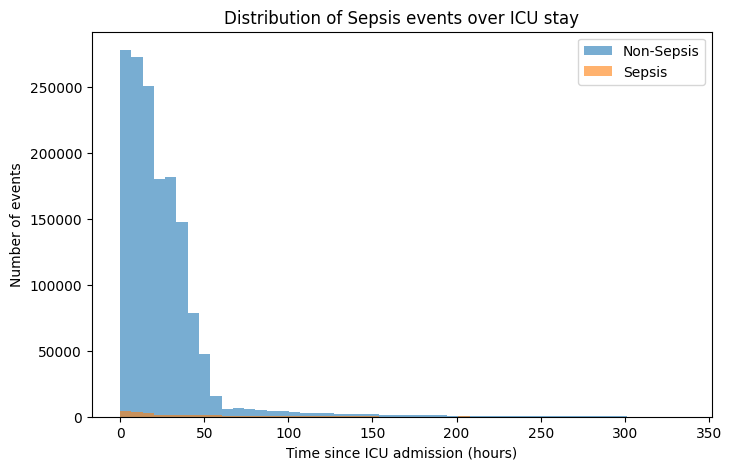

In [4]:
import matplotlib.pyplot as plt

# Sepsis vs Non-sepsis theo thời gian ICU (hour)
sepsis_hour = X.loc[X['SepsisLabel'] == 1, 'hour']
non_sepsis_hour = X.loc[X['SepsisLabel'] == 0, 'hour']

plt.figure(figsize=(8,5))
plt.hist(non_sepsis_hour, bins=50, alpha=0.6, label='Non-Sepsis')
plt.hist(sepsis_hour, bins=50, alpha=0.6, label='Sepsis')
plt.xlabel("Time since ICU admission (hours)")
plt.ylabel("Number of events")
plt.legend()
plt.title("Distribution of Sepsis events over ICU stay")
plt.show()


/tmp/ipykernel_16/2201329347.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sepsis_rate = X.groupby('hour_bin')['SepsisLabel'].mean()


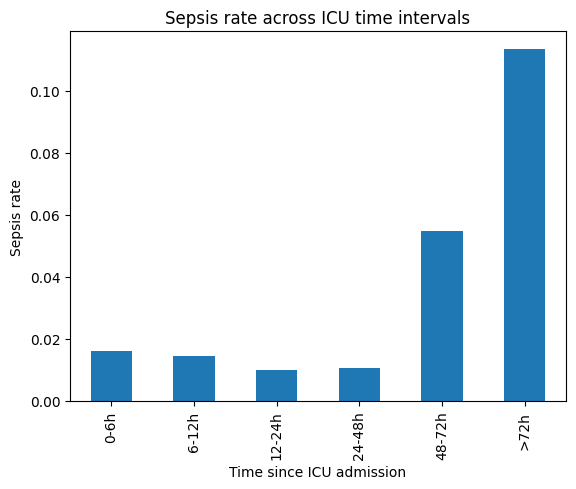

In [5]:
# Tạo bin theo giờ ICU
X['hour_bin'] = pd.cut(
    X['hour'],
    bins=[0, 6, 12, 24, 48, 72, 1000],
    labels=['0-6h', '6-12h', '12-24h', '24-48h', '48-72h', '>72h']
)

# Tính tỷ lệ Sepsis theo từng bin
sepsis_rate = X.groupby('hour_bin')['SepsisLabel'].mean()

sepsis_rate.plot(kind='bar')
plt.ylabel("Sepsis rate")
plt.xlabel("Time since ICU admission")
plt.title("Sepsis rate across ICU time intervals")
plt.show()

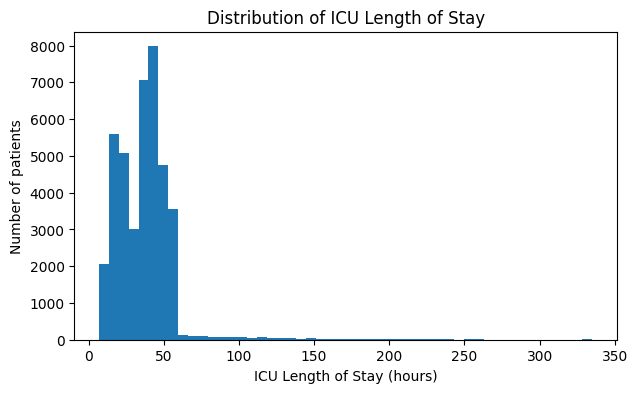

count    40336.000000
mean        37.482001
std         22.795923
min          7.000000
50%         37.000000
75%         46.000000
90%         54.000000
95%         57.000000
max        335.000000
Name: hour, dtype: float64

In [6]:
icu_los = X.groupby('id')['hour'].max()

plt.figure(figsize=(7,4))
plt.hist(icu_los, bins=50)
plt.xlabel('ICU Length of Stay (hours)')
plt.ylabel('Number of patients')
plt.title('Distribution of ICU Length of Stay')
plt.show()

icu_los.describe(percentiles=[0.5, 0.75, 0.9, 0.95])


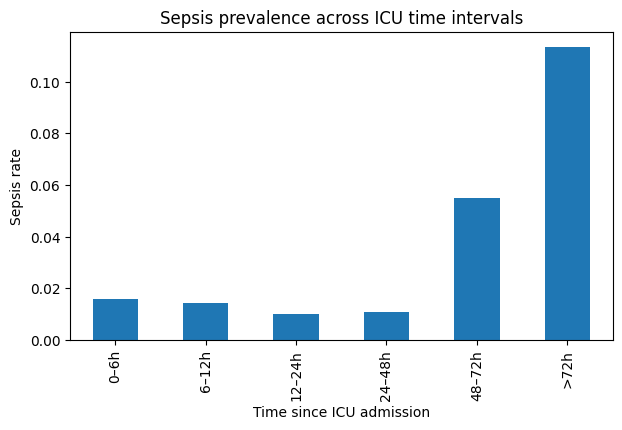

In [7]:
bins = [0, 6, 12, 24, 48, 72, X['hour'].max()]
labels = ['0–6h', '6–12h', '12–24h', '24–48h', '48–72h', '>72h']

X['hour_bin'] = pd.cut(X['hour'], bins=bins, labels=labels)

sepsis_rate = X.groupby('hour_bin', observed=False)['SepsisLabel'].mean()

plt.figure(figsize=(7,4))
sepsis_rate.plot(kind='bar')
plt.ylabel('Sepsis rate')
plt.xlabel('Time since ICU admission')
plt.title('Sepsis prevalence across ICU time intervals')
plt.show()


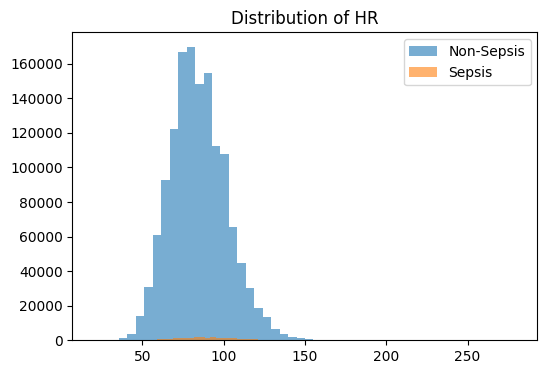

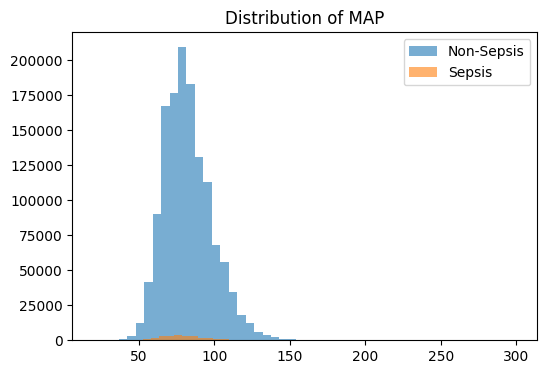

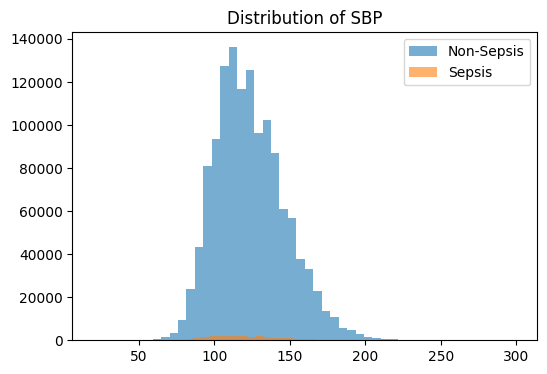

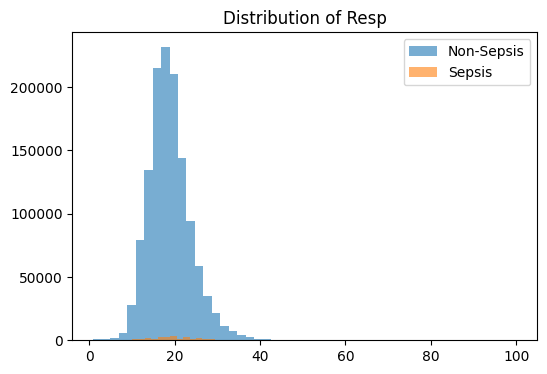

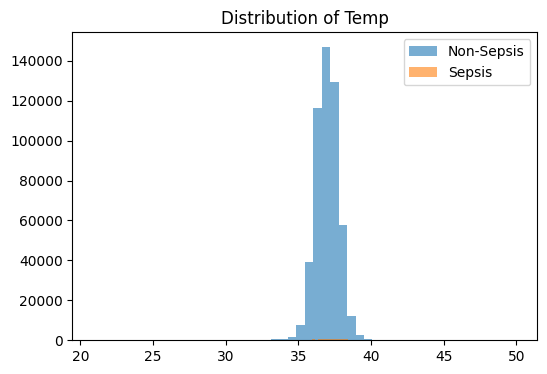

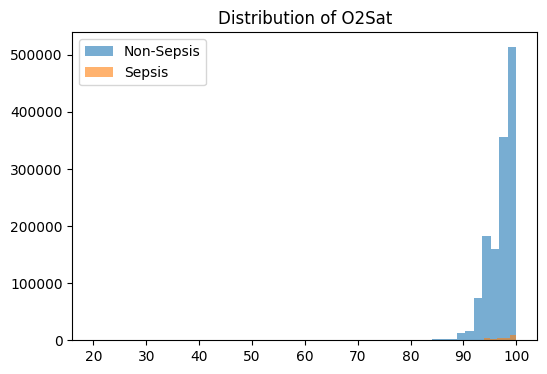

In [8]:
vitals = ['HR', 'MAP', 'SBP', 'Resp', 'Temp', 'O2Sat']

for col in vitals:
    plt.figure(figsize=(6,4))
    plt.hist(X[X['SepsisLabel']==0][col], bins=50, alpha=0.6, label='Non-Sepsis')
    plt.hist(X[X['SepsisLabel']==1][col], bins=50, alpha=0.6, label='Sepsis')
    plt.title(f'Distribution of {col}')
    plt.legend()
    plt.show()


/tmp/ipykernel_16/3237593872.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


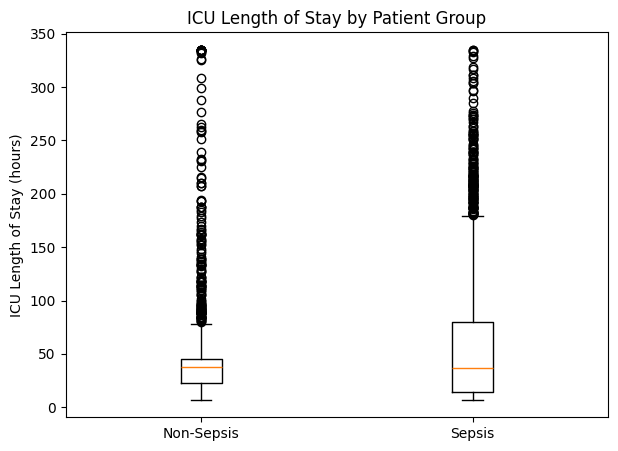

Sepsis
0    38.0
1    36.5
Name: ICU_LOS, dtype: float64

In [9]:
# ICU length of stay per patient
icu_los = X.groupby('id')['hour'].max()

# Patient-level sepsis label
patient_sepsis = X.groupby('id')['SepsisLabel'].max()

df_los = pd.DataFrame({
    'ICU_LOS': icu_los,
    'Sepsis': patient_sepsis
})

plt.figure(figsize=(7,5))
plt.boxplot(
    [df_los[df_los['Sepsis']==0]['ICU_LOS'],
     df_los[df_los['Sepsis']==1]['ICU_LOS']],
    labels=['Non-Sepsis', 'Sepsis']
)
plt.ylabel('ICU Length of Stay (hours)')
plt.title('ICU Length of Stay by Patient Group')
plt.show()

df_los.groupby('Sepsis')['ICU_LOS'].describe()
df_los.groupby('Sepsis')['ICU_LOS'].median()



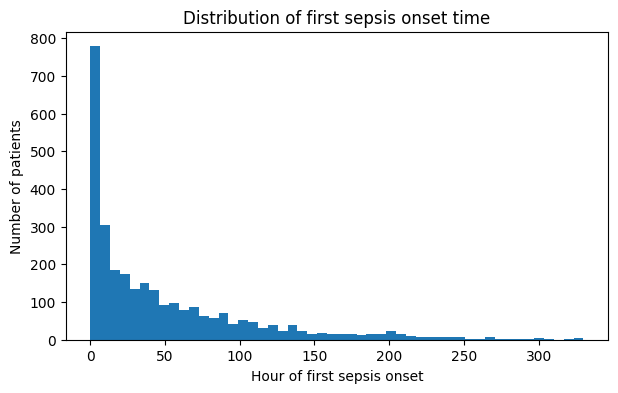

In [10]:
first_sepsis_time = (
    X[X['SepsisLabel']==1]
    .groupby('id')['hour']
    .min()
)

plt.figure(figsize=(7,4))
plt.hist(first_sepsis_time, bins=50)
plt.xlabel('Hour of first sepsis onset')
plt.ylabel('Number of patients')
plt.title('Distribution of first sepsis onset time')
plt.show()


/tmp/ipykernel_16/396563414.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


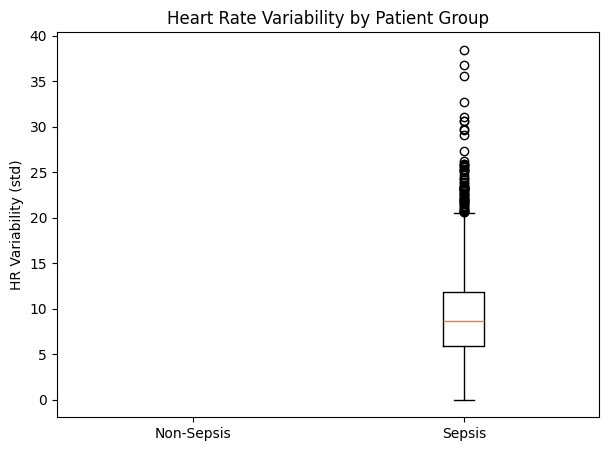

,count,mean,std,min,25%,50%,75%,max
Sepsis,,,,,,,,
0,37387.0,8.211258,4.055539,0.0,5.537188,7.454625,10.023646,76.367532
1,2932.0,9.283495,4.665378,0.0,5.947783,8.682179,11.788712,38.438023


In [11]:
# HR variability per patient
hr_var = X.groupby('id')['HR'].std()
patient_sepsis = X.groupby('id')['SepsisLabel'].max()

df_hrv = pd.DataFrame({
    'HR_std': hr_var,
    'Sepsis': patient_sepsis
})

plt.figure(figsize=(7,5))
plt.boxplot(
    [df_hrv[df_hrv['Sepsis']==0]['HR_std'],
     df_hrv[df_hrv['Sepsis']==1]['HR_std']],
    labels=['Non-Sepsis', 'Sepsis']
)
plt.ylabel('HR Variability (std)')
plt.title('Heart Rate Variability by Patient Group')
plt.show()

df_hrv.groupby('Sepsis')['HR_std'].describe()


In [12]:
# Cấu hình chung

XTICKS_ONSET = [-24, -18, -12, -6, -3, -1, 0]

def format_onset_axis(ax, xmin=-24, xmax=0, xlabel='Hours relative to onset (0 = onset)'):
    ax.set_xlim(xmin - 0.2, xmax + 0.2)
    ax.set_xticks(XTICKS_ONSET)
    ax.tick_params(axis='x', labelbottom=True)
    ax.set_xlabel(xlabel)
    ax.axvline(0, linestyle='--', alpha=0.8)
    ax.grid(alpha=0.3)


## Onset-centric temporal analysis

In [13]:
# Onset-centric setup
ID_COL = 'id'
TIME_COL = 'hour'
LABEL_COL = 'SepsisLabel'
WINDOW_HOURS = 24   
TIME_RANGE = (-WINDOW_HOURS, 0)

VITAL_CANDIDATES = ['HR', 'MAP', 'SBP', 'DBP', 'Resp', 'Temp', 'O2Sat']
LAB_CANDIDATES = ['WBC', 'Platelets', 'Creatinine', 'Bilirubin_total', 'Lactate']
VITALS = [c for c in VITAL_CANDIDATES if c in X.columns]
LABS = [c for c in LAB_CANDIDATES if c in X.columns]

print("Using vitals:", VITALS)
print("Using labs  :", LABS)

# Patient-level label
patient_label = X.groupby(ID_COL)[LABEL_COL].max()

# Positive patients and first onset
first_onset = (
    X[X[LABEL_COL] == 1]
    .groupby(ID_COL)[TIME_COL]
    .min()
    .rename('onset_hour')
    .reset_index()
)

print("Positive patients with onset:", len(first_onset))
display(first_onset.head())

Using vitals: ['HR', 'MAP', 'SBP', 'DBP', 'Resp', 'Temp', 'O2Sat']
Using labs  : ['WBC', 'Platelets', 'Creatinine', 'Bilirubin_total', 'Lactate']
Positive patients with onset: 2932


,id,onset_hour
0,8,248
1,10,24
2,14,5
3,17,125
4,21,9


In [14]:
# Build onset-aligned dataframe for sepsis patients
sepsis_aligned = X.merge(first_onset, on=ID_COL, how='inner').copy()
sepsis_aligned['time_to_onset'] = sepsis_aligned[TIME_COL] - sepsis_aligned['onset_hour']

# Keep only the window before onset
sepsis_pre_onset = sepsis_aligned[
    sepsis_aligned['time_to_onset'].between(TIME_RANGE[0], TIME_RANGE[1])
].copy()

print("Rows in onset-aligned sepsis window:", len(sepsis_pre_onset))
print("Unique sepsis patients in window:", sepsis_pre_onset[ID_COL].nunique())
print("time_to_onset range:", sepsis_pre_onset['time_to_onset'].min(), "to", sepsis_pre_onset['time_to_onset'].max())

sepsis_pre_onset[[ID_COL, TIME_COL, 'onset_hour', 'time_to_onset', LABEL_COL]].head()


Rows in onset-aligned sepsis window: 49866
Unique sepsis patients in window: 2932
time_to_onset range: -24 to 0


,id,hour,onset_hour,time_to_onset,SepsisLabel
224,8,224,248,-24,0
225,8,225,248,-23,0
226,8,226,248,-22,0
227,8,227,248,-21,0
228,8,228,248,-20,0


### 1. Mean trajectories of raw vital signs before onset
#### Trước khi sepsis xảy ra, các dấu hiệu sinh tồn thay đổi ra sao?

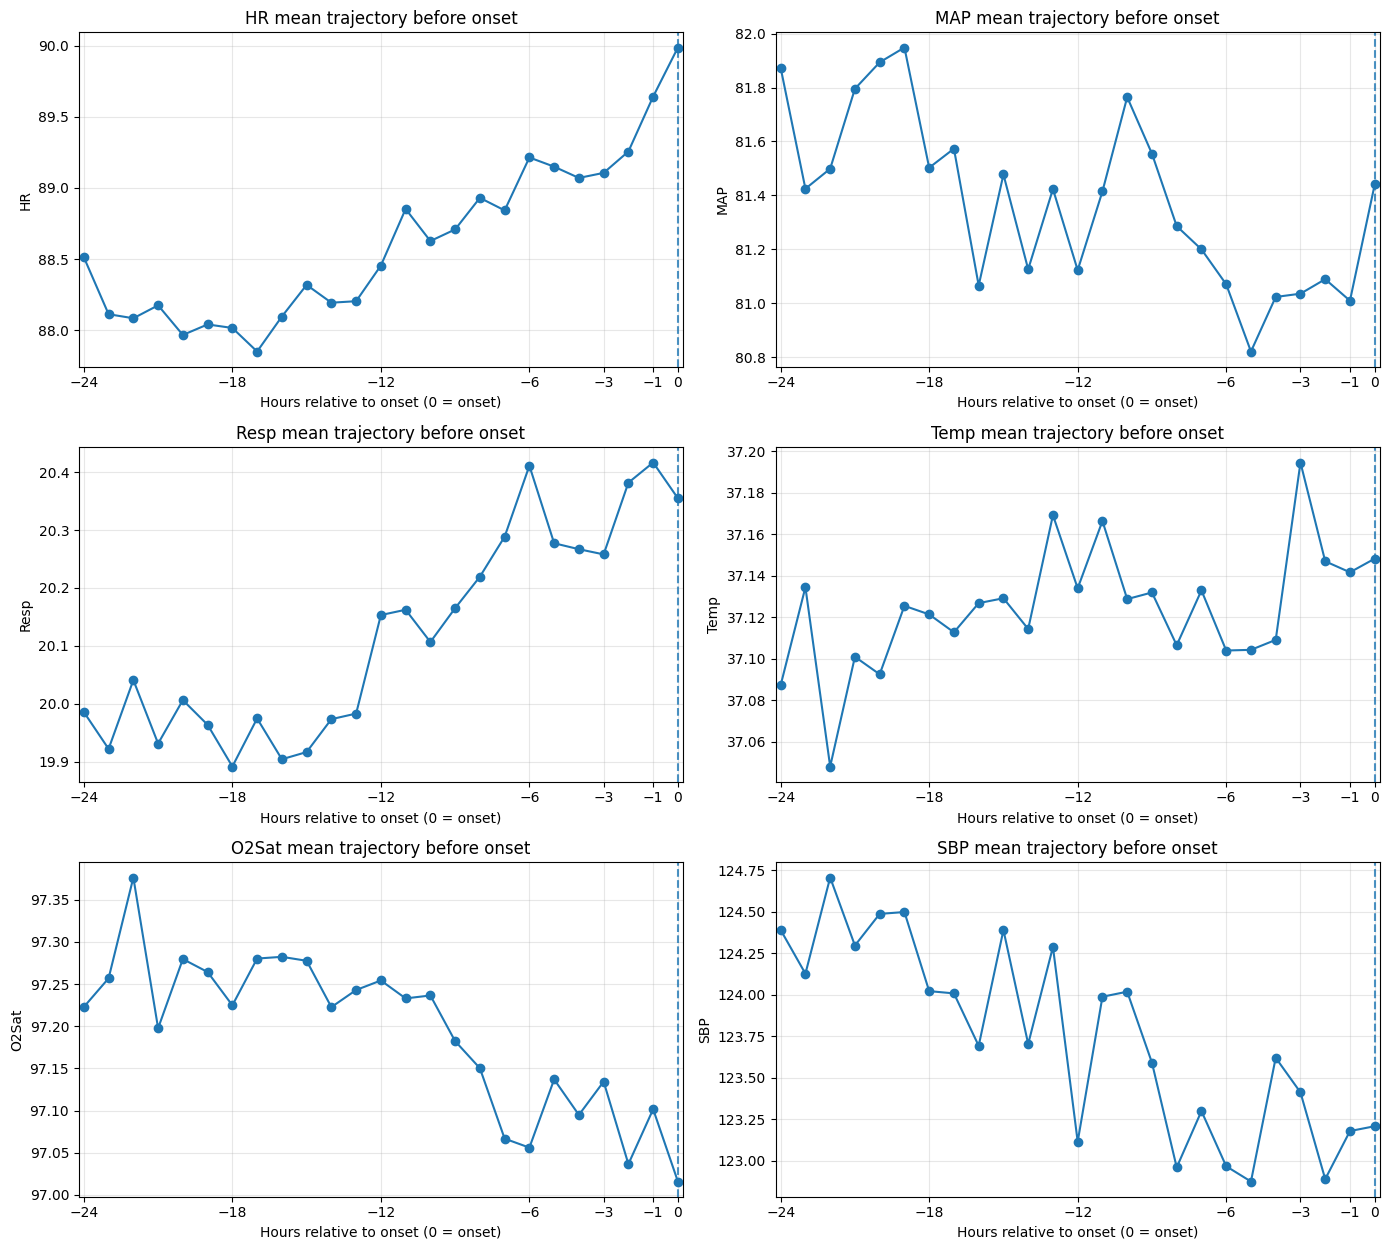

In [15]:
import matplotlib.pyplot as plt
import math

features_to_plot = [c for c in ['HR', 'MAP', 'Resp', 'Temp', 'O2Sat', 'SBP'] if c in sepsis_pre_onset.columns]

if not features_to_plot:
    raise ValueError("Không tìm thấy các vital signs cần thiết trong dataframe.")

n = len(features_to_plot)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows), sharex=False)
axes = axes.flatten()

for ax, col in zip(axes, features_to_plot):
    tmp = (
        sepsis_pre_onset.groupby('time_to_onset')[col]
        .mean()
        .reset_index()
        .sort_values('time_to_onset')
    )
    ax.plot(tmp['time_to_onset'], tmp[col], marker='o')
    ax.set_title(f'{col} mean trajectory before onset')
    ax.set_ylabel(col)
    format_onset_axis(ax, xmin=TIME_RANGE[0], xmax=TIME_RANGE[1])

plt.tight_layout()
plt.show()


### 2. Measurement density and missingness before onset
- Càng gần onset, bệnh nhân có được đo dày hơn không?
- Tỷ lệ missing có thay đổi không?

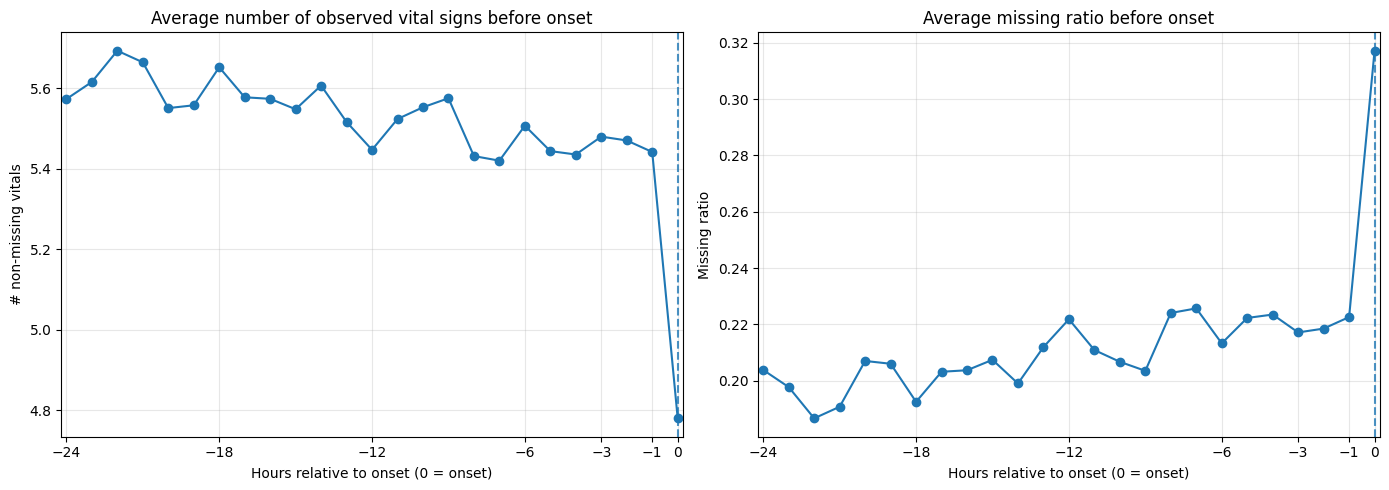

In [16]:
analysis_features = [c for c in VITALS if c in sepsis_pre_onset.columns]

density_df = sepsis_pre_onset.copy()
density_df['non_missing_count'] = density_df[analysis_features].notna().sum(axis=1)
density_df['missing_ratio'] = 1 - density_df[analysis_features].notna().mean(axis=1)

density_traj = (
    density_df.groupby('time_to_onset')[['non_missing_count', 'missing_ratio']]
    .mean()
    .reset_index()
    .sort_values('time_to_onset')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)

axes[0].plot(density_traj['time_to_onset'], density_traj['non_missing_count'], marker='o')
axes[0].set_title('Average number of observed vital signs before onset')
axes[0].set_ylabel('# non-missing vitals')
format_onset_axis(axes[0], xmin=TIME_RANGE[0], xmax=TIME_RANGE[1])

axes[1].plot(density_traj['time_to_onset'], density_traj['missing_ratio'], marker='o')
axes[1].set_title('Average missing ratio before onset')
axes[1].set_ylabel('Missing ratio')
format_onset_axis(axes[1], xmin=TIME_RANGE[0], xmax=TIME_RANGE[1])

plt.tight_layout()
plt.show()


### 3. Compare sepsis trajectories with non-sepsis reference trajectories

In [17]:
# Build reference-aligned dataframe for non-sepsis patients
non_sepsis_ids = patient_label[patient_label == 0].index
non_sepsis_raw = X[X[ID_COL].isin(non_sepsis_ids)].copy()

non_ref = (
    non_sepsis_raw.groupby(ID_COL)[TIME_COL]
    .max()
    .rename('ref_hour')
    .reset_index()
)

non_aligned = non_sepsis_raw.merge(non_ref, on=ID_COL, how='left').copy()
non_aligned['time_to_ref'] = non_aligned[TIME_COL] - non_aligned['ref_hour']

non_window = non_aligned[
    non_aligned['time_to_ref'].between(TIME_RANGE[0], TIME_RANGE[1])
].copy()

print("Rows in non-sepsis reference window:", len(non_window))
print("Unique non-sepsis patients in window:", non_window[ID_COL].nunique())

Rows in non-sepsis reference window: 876907
Unique non-sepsis patients in window: 37404


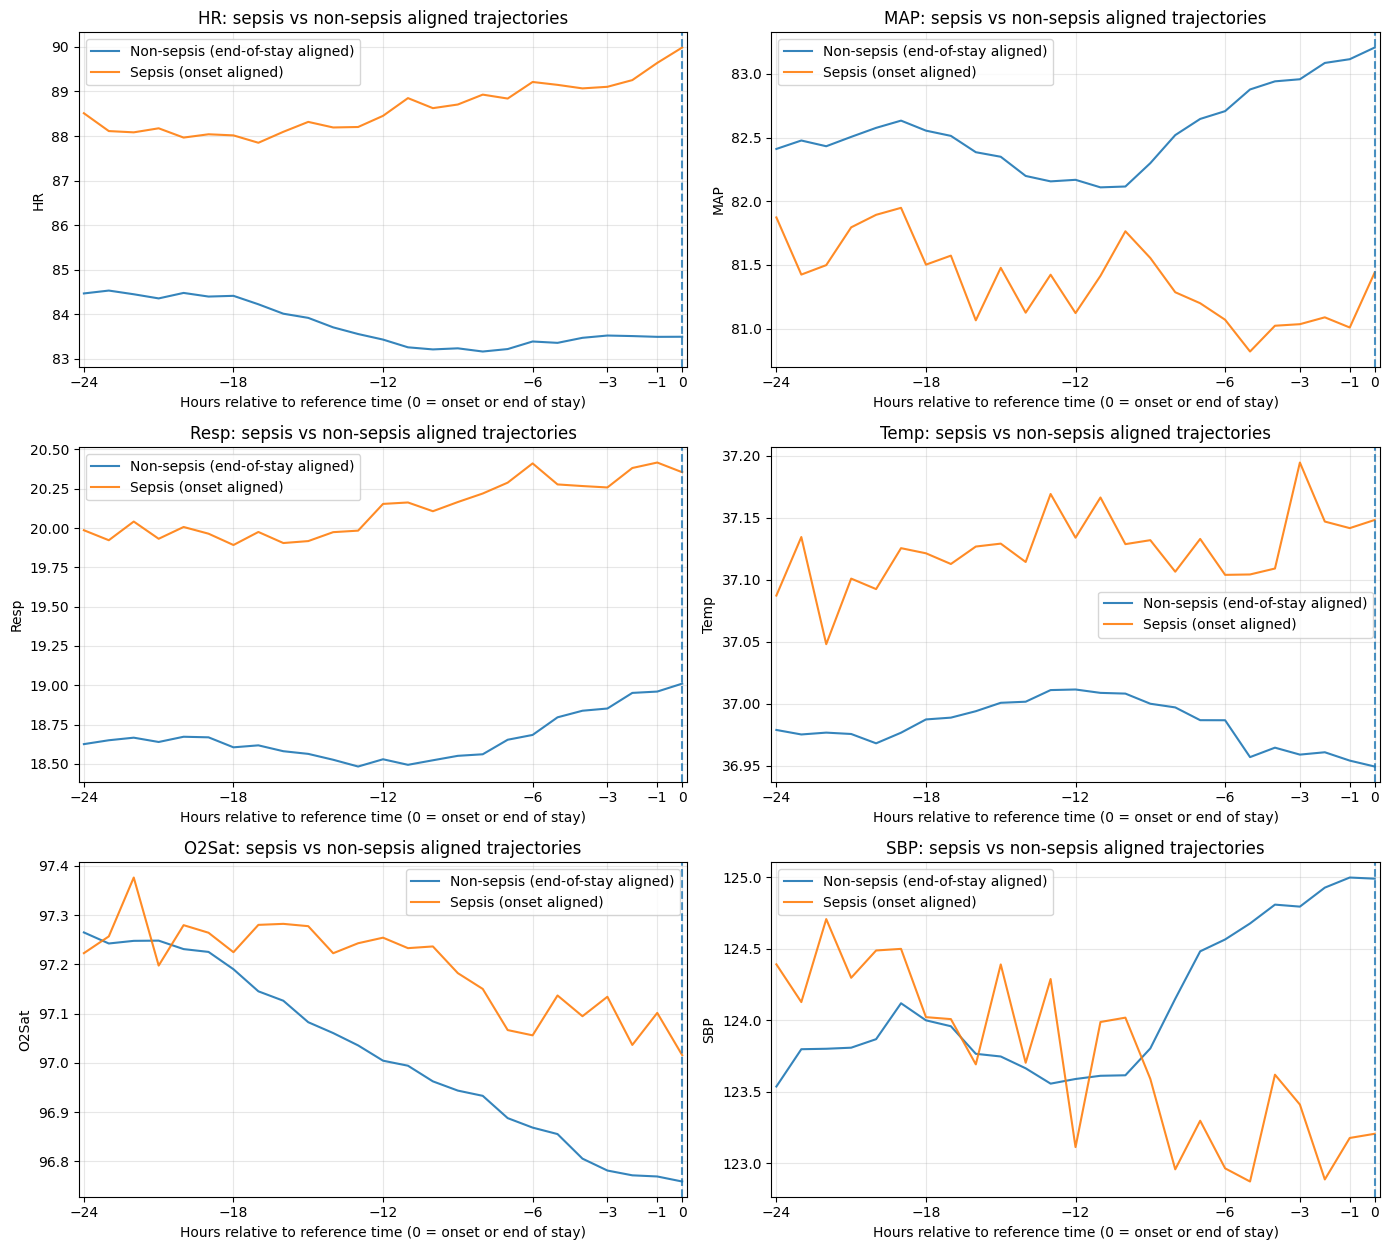

In [18]:
compare_features = [c for c in ['HR', 'MAP', 'Resp', 'Temp', 'O2Sat', 'SBP'] if c in X.columns]

n = len(compare_features)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.2 * nrows), sharex=False)
axes = axes.flatten()

for ax, col in zip(axes, compare_features):
    sepsis_tmp = (
        sepsis_pre_onset.groupby('time_to_onset')[col]
        .mean()
        .reset_index()
        .rename(columns={'time_to_onset': 't', col: 'value'})
        .sort_values('t')
    )
    non_tmp = (
        non_window.groupby('time_to_ref')[col]
        .mean()
        .reset_index()
        .rename(columns={'time_to_ref': 't', col: 'value'})
        .sort_values('t')
    )

    ax.plot(non_tmp['t'], non_tmp['value'], label='Non-sepsis (end-of-stay aligned)', alpha=0.9)
    ax.plot(sepsis_tmp['t'], sepsis_tmp['value'], label='Sepsis (onset aligned)', alpha=0.9)
    ax.set_title(f'{col}: sepsis vs non-sepsis aligned trajectories')
    ax.set_ylabel(col)
    format_onset_axis(ax, xmin=TIME_RANGE[0], xmax=TIME_RANGE[1], xlabel='Hours relative to reference time (0 = onset or end of stay)')
    ax.legend()

plt.tight_layout()
plt.show()